<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB3_2_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción práctica a Fashion MNIST

En esta libreta trabajaremos con el conjunto de datos **Fashion MNIST** para construir dos enfoques de clasificación de imágenes:

1. Un modelo base tipo **Regresión Múltiple con Softmax**, implementado como una red neuronal superficial con una capa `Flatten` de entrada.
2. Un modelo basado en **Convolutional Neural Network**.
3. Una **comparativa final** entre ambos enfoques.

La intención es observar cómo cambia el desempeño cuando se pasa de un modelo que trata la imagen como un vector plano a un modelo que aprovecha mejor la estructura espacial de la imagen.

## Objetivos de trabajo

Al finalizar esta libreta podrás:

- Cargar y explorar el conjunto de datos Fashion MNIST.
- Preparar imágenes y etiquetas para un problema de clasificación multiclase.
- Entrenar un modelo base con `Flatten + Dense(softmax)`.
- Entrenar un modelo convolucional.
- Comparar métricas, número de parámetros y comportamiento general de ambos modelos.

## 1. Librerías

Usaremos `TensorFlow/Keras` para construir los modelos, `NumPy` para algunas operaciones básicas y `Matplotlib` para visualizar resultados.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## 2. Carga del conjunto de datos Fashion MNIST

Fashion MNIST contiene imágenes en escala de grises de tamaño **28 × 28**. Cada imagen pertenece a una de diez categorías de prendas o accesorios.

A continuación cargamos el conjunto de entrenamiento y el conjunto de prueba.

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)


### Vista rápida de algunas imágenes

Antes de entrenar modelos, conviene observar ejemplos del conjunto de datos para identificar el tipo de patrones que el modelo deberá aprender.

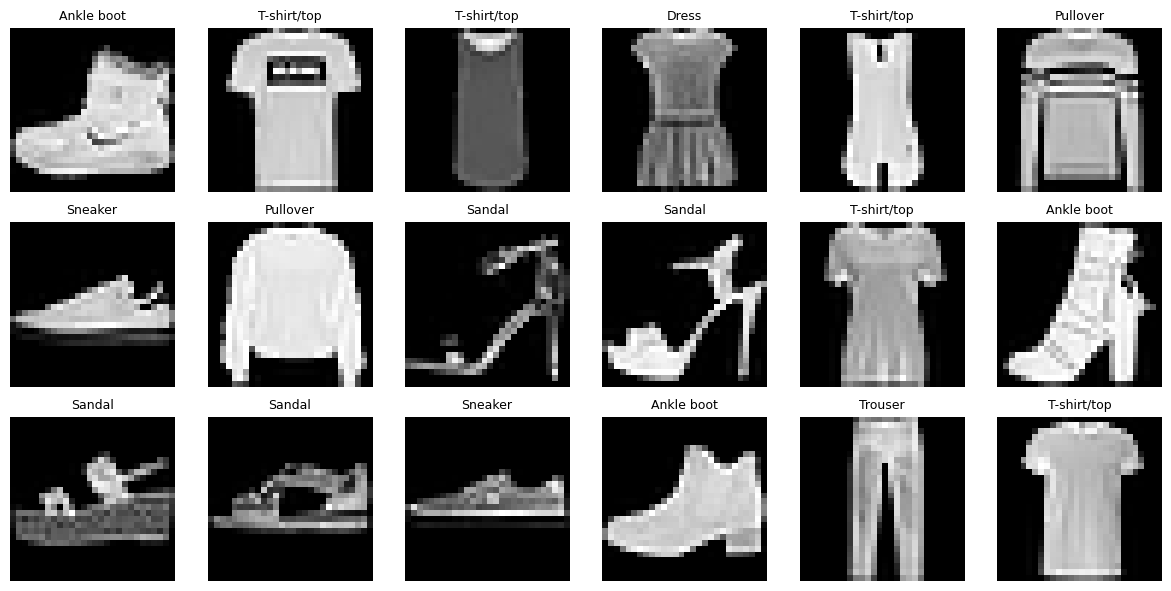

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preparación de los datos

Las imágenes vienen con valores enteros entre 0 y 255. Para facilitar el entrenamiento, las escalamos al rango **[0, 1]**.

Primero generaremos una versión normalizada para el modelo base. Más adelante prepararemos una segunda versión con dimensión de canal para el modelo convolucional.

In [ ]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Rango mínimo y máximo en entrenamiento:")
print(x_train_norm.min(), x_train_norm.max())

Rango mínimo y máximo en entrenamiento:
0.0 1.0


## 4. Modelo base: Regresión Múltiple con Softmax

En este primer enfoque, la imagen se transforma en un vector plano por medio de una capa `Flatten`. Después, una capa densa con activación `softmax` produce la probabilidad estimada para cada una de las 10 clases.

Este modelo sirve como punto de referencia inicial.

In [ ]:
softmax_model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

softmax_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

softmax_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo base

Usaremos una fracción del conjunto de entrenamiento como validación para observar el comportamiento del modelo durante el ajuste.

In [ ]:
start_time = time.time()

history_softmax = softmax_model.fit(
    x_train_norm,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

softmax_train_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {softmax_train_time:.2f} segundos")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7522 - loss: 0.7592 - val_accuracy: 0.8105 - val_loss: 0.5494
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8247 - loss: 0.5251 - val_accuracy: 0.8270 - val_loss: 0.4897
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8384 - loss: 0.4819 - val_accuracy: 0.8380 - val_loss: 0.4634
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8451 - loss: 0.4591 - val_accuracy: 0.8420 - val_loss: 0.4481
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8494 - loss: 0.4442 - val_accuracy: 0.8463 - val_loss: 0.4379
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8519 - loss: 0.4335 - val_accuracy: 0.8495 - val_loss: 0.4307
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8545 - loss: 0.4254 - val_accuracy: 0.8510 - val_loss: 0.4252
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8565 - loss: 0.4189 - val_accuracy: 0.

### Evaluación en el conjunto de prueba

In [ ]:
softmax_test_loss, softmax_test_acc = softmax_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"Test loss     : {softmax_test_loss:.4f}")
print(f"Test accuracy : {softmax_test_acc:.4f}")

Test loss     : 0.4474
Test accuracy : 0.8427


### Evolución de pérdida y exactitud

Estas curvas permiten revisar si el modelo mejora con las épocas y si existe una diferencia relevante entre entrenamiento y validación.

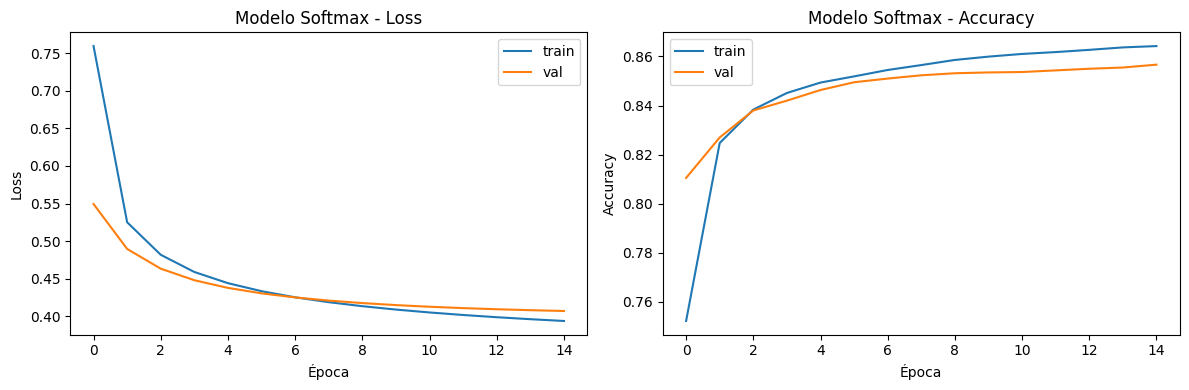

In [ ]:
def plot_history(history, title_prefix):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title_prefix} - Loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title_prefix} - Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_softmax, "Modelo Softmax")

### Matriz de confusión del modelo base

La matriz de confusión ayuda a detectar qué clases tienden a confundirse con más frecuencia.

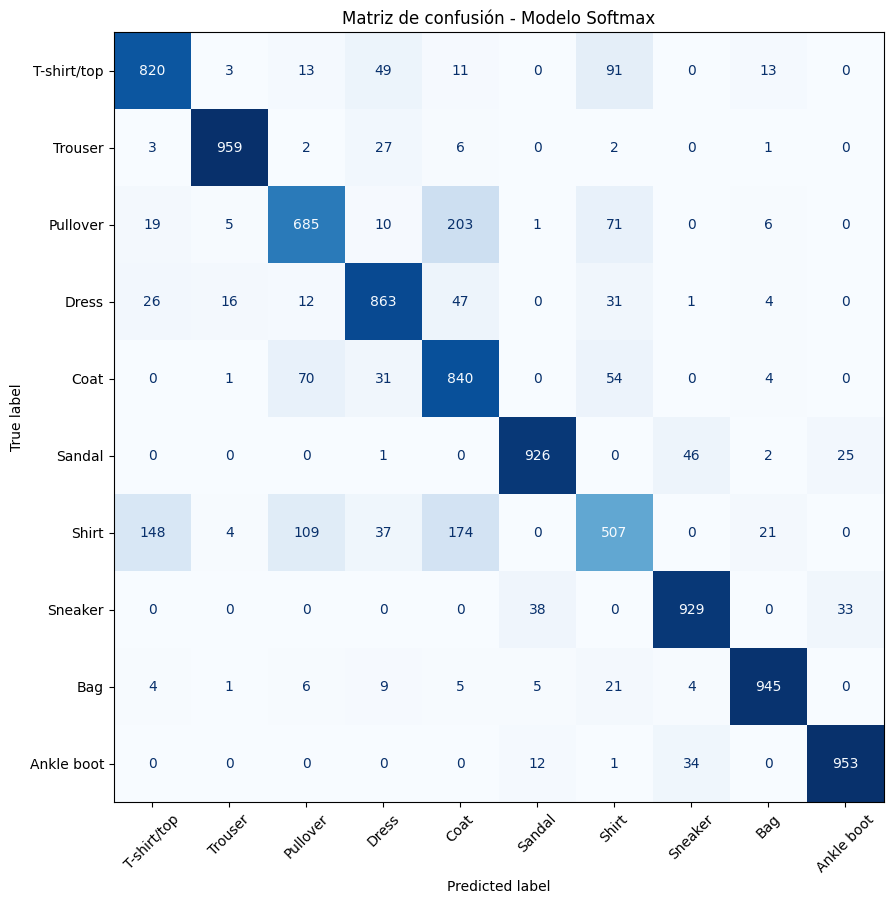

In [ ]:
y_pred_softmax = np.argmax(softmax_model.predict(x_test_norm, verbose=0), axis=1)

cm_softmax = confusion_matrix(y_test, y_pred_softmax)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_softmax, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Modelo Softmax")
plt.show()

### Algunas predicciones del modelo base

A continuación se muestran ejemplos del conjunto de prueba junto con la clase real y la clase predicha.

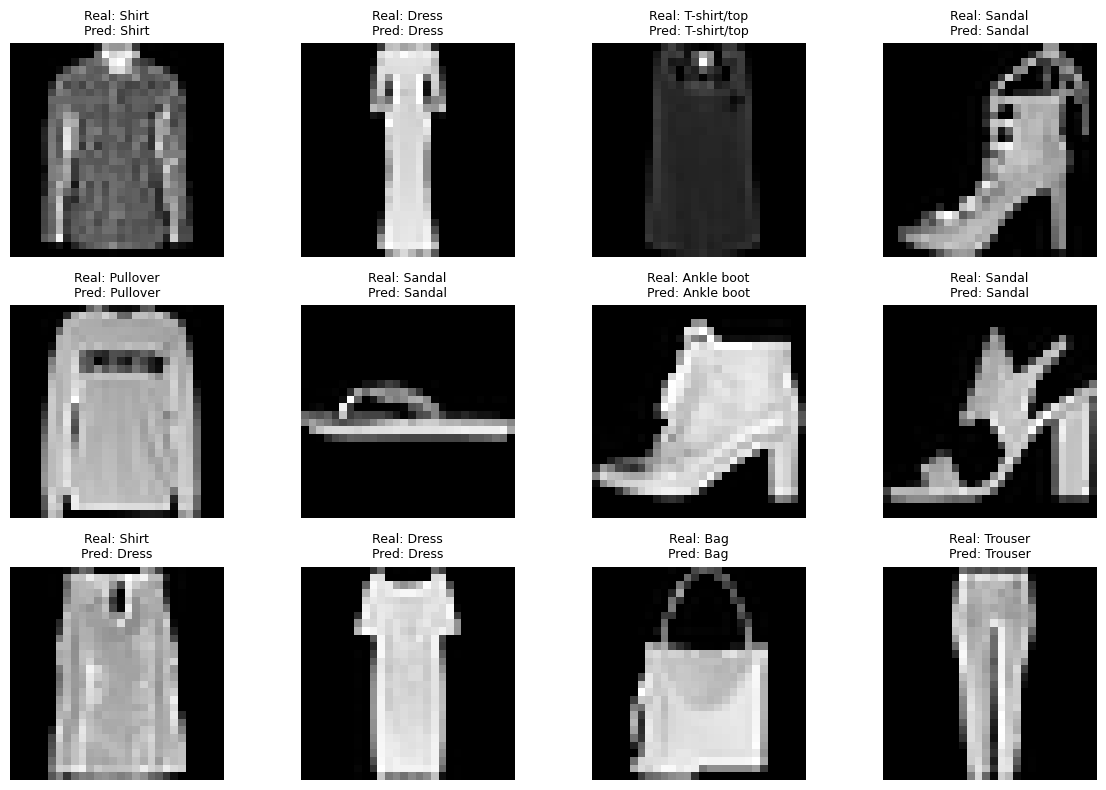

In [ ]:
indices = np.random.choice(len(x_test_norm), size=12, replace=False)
pred_probs_softmax = softmax_model.predict(x_test_norm[indices], verbose=0)
pred_labels_softmax = np.argmax(pred_probs_softmax, axis=1)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test_norm[idx], cmap="gray")
    real_label = class_names[y_test[idx]]
    pred_label = class_names[pred_labels_softmax[i]]
    plt.title(f"Real: {real_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Modelo convolucional

Para este segundo enfoque añadiremos una dimensión de canal, de modo que cada imagen tenga forma **28 × 28 × 1**.

Esto permite alimentar el modelo con la estructura habitual esperada en tareas de visión por computadora.

In [ ]:
x_train_cnn = np.expand_dims(x_train_norm, axis=-1)
x_test_cnn = np.expand_dims(x_test_norm, axis=-1)

print("Forma de x_train_cnn:", x_train_cnn.shape)
print("Forma de x_test_cnn :", x_test_cnn.shape)

Forma de x_train_cnn: (60000, 28, 28, 1)
Forma de x_test_cnn : (10000, 28, 28, 1)


### Arquitectura del modelo convolucional

Usaremos una arquitectura compacta para una primera aproximación práctica:

- Bloques convolucionales con activación ReLU
- Capas de max pooling
- Una capa densa final para clasificación multiclase

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo convolucional

In [ ]:
start_time = time.time()

history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

cnn_train_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {cnn_train_time:.2f} segundos")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 136ms/step - accuracy: 0.8121 - loss: 0.5247 - val_accuracy: 0.8737 - val_loss: 0.3403
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - accuracy: 0.8814 - loss: 0.3328 - val_accuracy: 0.8960 - val_loss: 0.2831
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - accuracy: 0.8969 - loss: 0.2844 - val_accuracy: 0.9042 - val_loss: 0.2642
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 134ms/step - accuracy: 0.9062 - loss: 0.2546 - val_accuracy: 0.9077 - val_loss: 0.2551
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 134ms/step - accuracy: 0.9154 - loss: 0.2322 - val_accuracy: 0.9085 - val_loss: 0.2504
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 55s 131ms/step - accuracy: 0.9219 - loss: 0.2126 - val_accuracy: 0.9088 - val_loss: 0.2474
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.9270 - loss: 0.1975 - val_accuracy: 0.9112 - val_loss: 0.2373
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.9331 - loss: 0

### Evaluación en el conjunto de prueba

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)

print(f"Test loss     : {cnn_test_loss:.4f}")
print(f"Test accuracy : {cnn_test_acc:.4f}")

Test loss     : 0.2453
Test accuracy : 0.9159


### Evolución de pérdida y exactitud del modelo convolucional

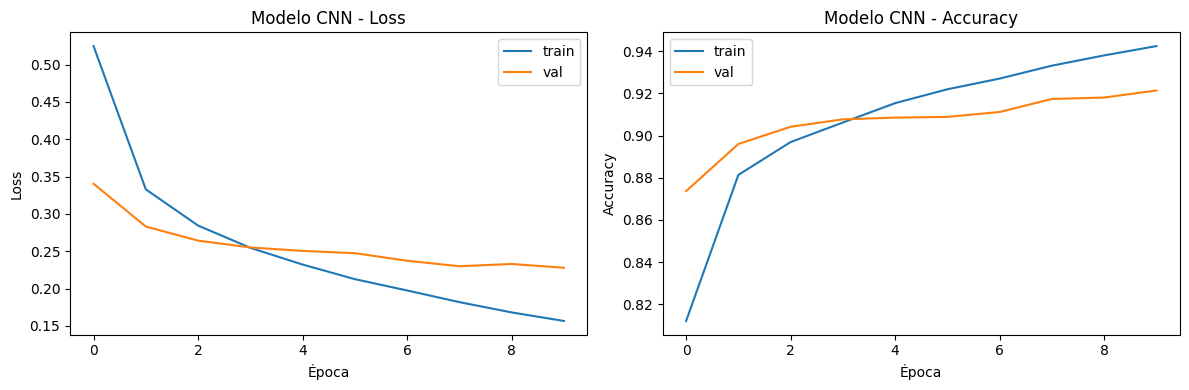

In [ ]:
plot_history(history_cnn, "Modelo CNN")

### Matriz de confusión del modelo convolucional

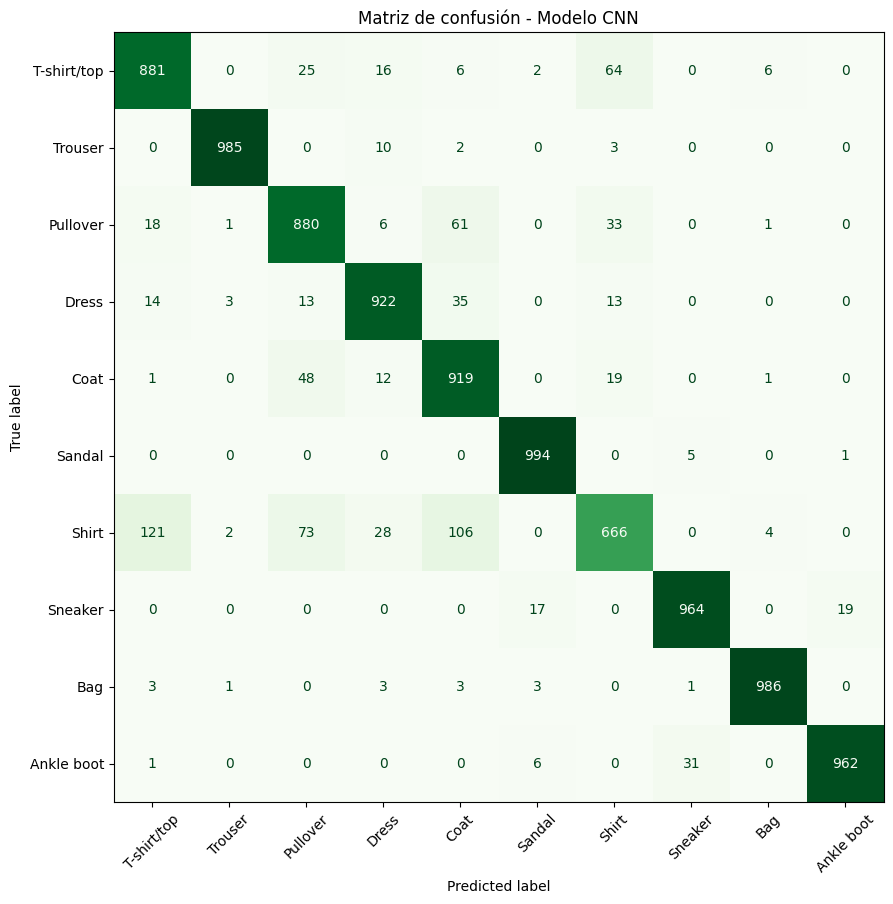

In [ ]:
y_pred_cnn = np.argmax(cnn_model.predict(x_test_cnn, verbose=0), axis=1)

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Greens", colorbar=False)
plt.title("Matriz de confusión - Modelo CNN")
plt.show()

### Algunas predicciones del modelo convolucional

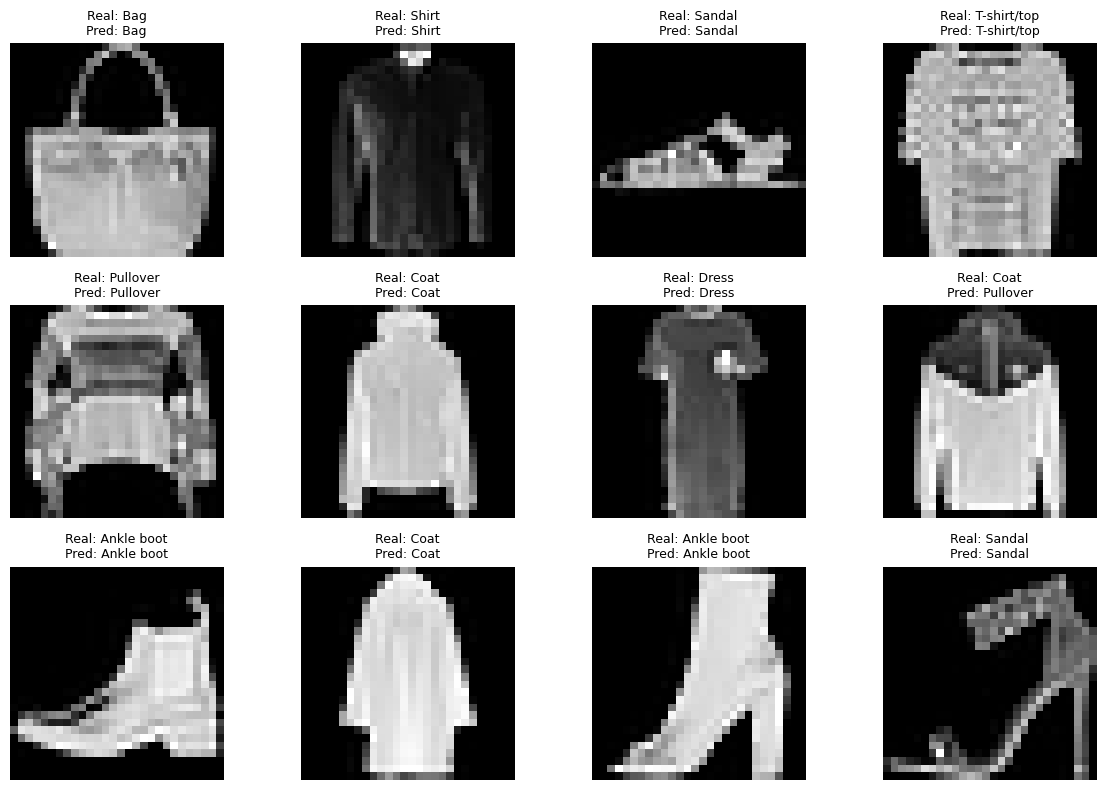

In [ ]:
indices = np.random.choice(len(x_test_cnn), size=12, replace=False)
pred_probs_cnn = cnn_model.predict(x_test_cnn[indices], verbose=0)
pred_labels_cnn = np.argmax(pred_probs_cnn, axis=1)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test_cnn[idx].squeeze(), cmap="gray")
    real_label = class_names[y_test[idx]]
    pred_label = class_names[pred_labels_cnn[i]]
    plt.title(f"Real: {real_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Comparativa final

Reunimos en una sola tabla algunos elementos clave:

- Pérdida en prueba
- Exactitud en prueba
- Número de parámetros
- Tiempo de entrenamiento

Esto permite contrastar de forma directa el modelo base y el modelo convolucional.

In [ ]:
results = pd.DataFrame([
    {
        "Modelo": "Softmax + Flatten",
        "Test loss": softmax_test_loss,
        "Test accuracy": softmax_test_acc,
        "Parámetros": softmax_model.count_params(),
        "Tiempo entrenamiento (s)": softmax_train_time
    },
    {
        "Modelo": "CNN",
        "Test loss": cnn_test_loss,
        "Test accuracy": cnn_test_acc,
        "Parámetros": cnn_model.count_params(),
        "Tiempo entrenamiento (s)": cnn_train_time
    }
])

results

,Modelo,Test loss,Test accuracy,Parámetros,Tiempo entrenamiento (s)
0,Softmax + Flatten,0.447437,0.8427,7850,22.918313
1,CNN,0.245316,0.9159,421642,668.137699


### Visualización comparativa

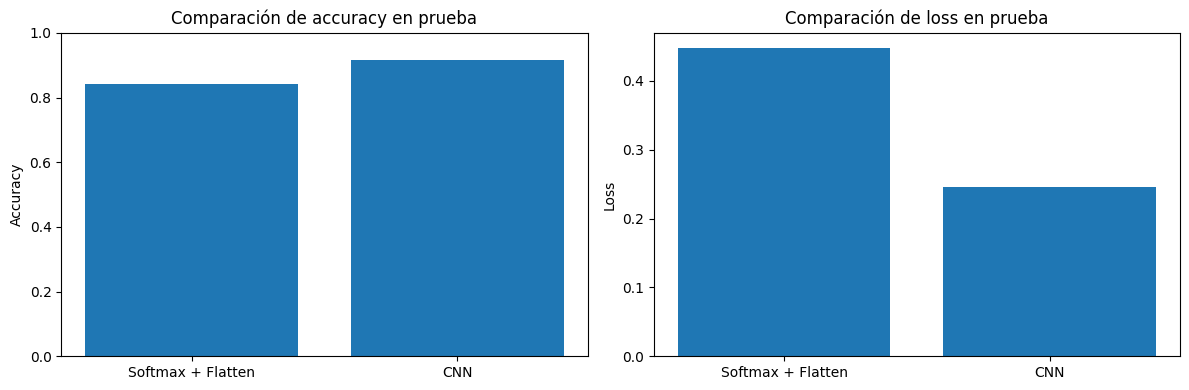

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results["Modelo"], results["Test accuracy"])
axes[0].set_title("Comparación de accuracy en prueba")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(results["Modelo"], results["Test loss"])
axes[1].set_title("Comparación de loss en prueba")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## 7. Cierre

Con esta práctica se puede observar lo siguiente:

- Fashion MNIST es un buen punto de partida para experimentar con clasificación de imágenes.
- Un modelo con `Flatten + Dense(softmax)` ofrece una línea base clara y rápida de entrenar.
- El modelo convolucional suele alcanzar un mejor desempeño al trabajar directamente con la estructura de la imagen.
- La comparación final permite discutir no solo exactitud, sino también costo computacional, número de parámetros y comportamiento general del entrenamiento.